<a href="https://colab.research.google.com/github/Morganjools/PRA3024/blob/main/Final_GW_tutorial_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### GW tutorial 3: Generation of data and matched filtering

Author: Melissa Lopez

Email: m.lopez@uu.nl

In [ ]:
!pip install pycbc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.4/9.4 MB 46.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 MB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.1/51.1 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.1/203.1 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.2/45.2 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.7/168.7 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.0/115.0 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.1/48.1 MB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 32.1 MB/s eta 0:00:00
  Attempting uninstall: cryptography
    Found existing installation: cryptography 43.0.3
    Uninstalling cryptography-43.0.3:
      Successfully uninstalled cryptography-43.0.3
ERROR: pip's dependency resolver d

In [ ]:
%matplotlib inline
from pycbc.catalog import Merger
import pycbc.psd, pycbc.noise
import pylab
import matplotlib.pyplot as plt
import numpy as np
from pycbc.waveform import get_td_waveform
from pycbc.detector import Detector
import random

/usr/local/lib/python3.12/dist-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal


In [ ]:
%matplotlib inline
from pycbc.catalog import Merger
import pycbc.psd, pycbc.noise
import pylab
import matplotlib.pyplot as plt
import numpy as np
from pycbc.waveform import get_td_waveform
from pycbc.detector import Detector
import random

Previously, we have plotted the PSD of different detectors. Some PSDs are from previous runs (O3), while some others are the design sensitivity of future detectors.

The PSD characterizes the noise of the detector, so we can generate detector noise accordingly.

**Exercise 1:** Load the `aligo_O4high.txt` PSD to [generate](https://pycbc.org/pycbc/latest/html/pycbc.noise.html#pycbc.noise.gaussian.noise_from_psd) some Gaussian data.

_Hint:_ Minimum frequency is 10 Hz, sampling rate 4096 Hz and we want 20s of duration

In [ ]:
!ls /content/aligo_O4high.txt #make sure the txt file is in content map and this file was downloaded directly from LIGO

/content/aligo_O4high.txt


In [ ]:
aligo_O4high = np.loadtxt("/content/aligo_O4high.txt")


In [72]:
#Rename the data of the txt file
data = np.loadtxt("/content/aligo_O4high.txt")

#Txt file has two columns: first is frequencies and second the psd values. With this you assign the columns.
frequencies = data[:, 0]
psd_values = data[:, 1]

#Define the parameters
delta_t = 1.0 / 4096 #delta_t= 1/ sample rate
duration = 20
length = int(duration / delta_t) #Integer of length of noise

#Frequency resolution needed by FFT
delta_f = 1.0 / duration
psd_length = length // 2 + 1 #Hermitian symmetry for FFT, obtained from: https://stackoverflow.com/questions/70758915/is-a-numpy-fft-on-real-values-actually-hermitian

#Create PSD directly at Hermitian symmetry length
psd = from_numpy_arrays(frequencies, psd_values, length=psd_length, delta_f=delta_f, low_freq_cutoff=frequencies[10])

#Generate Gaussian noise from equation
noise = noise_from_psd(length=length, delta_t=delta_t, psd=psd, seed=None)

print(noise)

#Printing the values of the parameters used:
print('Amount of data points:', len(data))
print('Delta f:', delta_f)
print('Delta t:', delta_t)

[ 1.45364218e-10 -4.17465654e-11 -1.82717866e-10 ... -1.35993323e-10
 -2.15868809e-10 -2.89828114e-11]
Amount of data points: 2736
Delta f: 0.05
Delta t: 0.000244140625


As you can see. the generated noise is "coloured" according to the detector noise. Now, we would like to add a simulated gravitational wave signal in our detector noise.

**Exercise 2:** Using [this function](https://pycbc.org/pycbc/latest/html/pycbc.waveform.html#pycbc.waveform.waveform.get_td_waveform) to generate waveforms in time domain, provide the plus and cross polarization of a binary black hole merger of $m_{1} = m_{2} = 50$ at 2000 Mpc. Use the waveform approximant "IMRPhenomD". How does the waveform amplitude compare to the detector noise?

The waveform comes from the source, but it needs to be projected in the detector. [Project](https://pycbc.org/pycbc/latest/html/pycbc.detector.html#pycbc.detector.ground.Detector.project_wave) the waveform on LIGO Livingston (L1) at random sky-location and polarization. You can specify your detector with [this](https://pycbc.org/pycbc/latest/html/pycbc.detector.html#pycbc.detector.ground.Detector) function. How does the waveform change because of this projection?

_Hint:_ Right ascension range is $[0, 2\pi]$, declination is $[-2\pi, 2\pi]$ and polarization is $[0, 2\pi]$.

In [53]:

#Function that returns the plus and cross polarizations of binary black hole merger
hplus, hcross = get_td_waveform(approximant="IMRPhenomD", mass1=50, mass2=50, distance=2000, delta_t=delta_t, f_lower=10)

#Define detector with function
det = Detector("L1", reference_time=1126259462.0)

#Random sky location and polarization within range needed for arrival time function
ra = np.random.uniform(0, 2*np.pi)
dec = np.random.uniform(-np.pi/2, np.pi/2)
polarization = np.random.uniform(0, 2*np.pi)

#Project waveform onto detector to return the waveform measured by detector
waveform_L1 = det.project_wave(hplus, hcross, ra, dec, polarization, method='lal', reference_time=None)

#Compute the maximum values so analysis is based on same values
print("Max |hplus|:", abs(hplus).max())
print("Max |hcross|:", abs(hcross).max())
print("Max |projected h|:", abs(waveform_L1).max())

print("Max |noise|:", abs(noise).max())

Max |hplus|: 5.956188055781745e-22
Max |hcross|: 5.914760742147031e-22
Max |projected h|: 3.273419673808924e-22
Max |noise|: 6.21636478426938e-10


**From these results, it seems that the projected waveform decreases compared to the waveform from the source by approx. half. The noise from the detector is very large compared to the amplitude of the waveform. This could explain why the projected waveform is so much smaller than the waveform from the source. This is because the signal to noise ratio decreases with increasing noise.**

**Exercise 3:** From before our detector noise is 20s long. Add the GW into noise after 5s. We also need to get the first 4s to estimate the PSD in the next excercise. Make an overlaid plot with the total data, the portion of data where the GW is added and the data needed to estimate the PSD.

_Bonus:_ Can you also plot the GW signal?


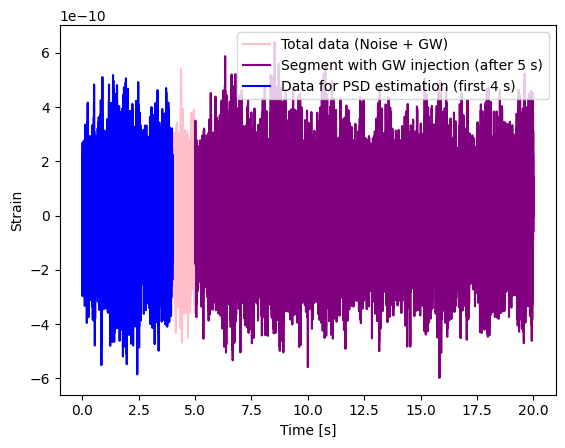

In [65]:
#Define the time where GW data will be added
inject_time = 5.0
start= int(inject_time / delta_t)

#Shift the start of waveform to the start time (5 seconds)
waveform_L1.start_time = inject_time

#Plotting the total data, GW after 5 seconds and PSD estimation for first 4 second
time = np.arange(length) * delta_t
plt.figure()
plt.plot(time, noise, label="Total data (Noise + GW)", color="pink")
plt.plot(time[start:start + len(waveform_L1)], noise[start:start + len(waveform_L1)], label="Segment with GW injection (after 5 s)", color="purple") #Using the data after 5 seconds
plt.plot(time[:int(4.0 / delta_t)], noise[:int(4.0 / delta_t)], label="Data for PSD estimation (first 4 s)", color="blue") #First 4 seconds, where legnth is duration over delta_t

plt.xlabel("Time [s]")
plt.ylabel("Strain") #Stretching and squeezing of spacetime due to GW
plt.legend()
plt.show()


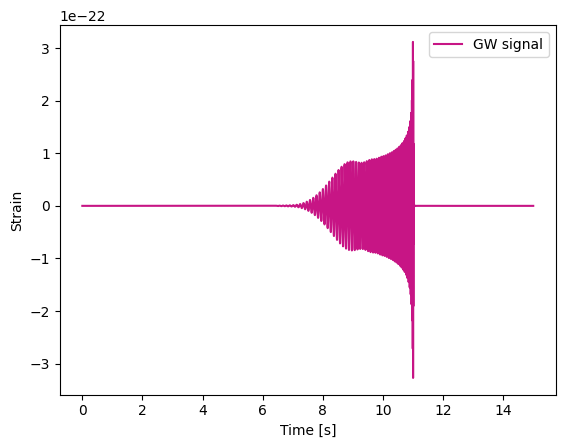

In [70]:
#Plotting GW signal against stretching ST
plt.figure()
#Created samples that correlate to the delta_t time steps used to generate waveform. Add the injected time so the signal doesn't start at 0 s.
plt.plot(np.arange(len(waveform_L1)) * delta_t + inject_time, waveform_L1, label="GW signal", color= "mediumvioletred")
plt.xlabel("Time [s]")
plt.ylabel("Strain") #no unit
plt.legend()
plt.show()


**Exercise 4:** In a proper search we do not really have the PSD handy. We want to estimate the PSD with Welch's method (see [here](https://ccrma.stanford.edu/~jos/sasp/Welch_s_Method.html) for details), but we want to use the 4s of the beginning where the GW is not present using [this function](https://pycbc.org/pycbc/latest/html/pycbc.psd.html#pycbc.psd.estimate.welch). Plot the estimated PSD. Note that before we used a dummy whitening, and this one is a bit better.

What is the $\Delta_f$ of the estimated PSD? What is $\Delta_f$ of the data we want to whiten to see the GW signal?

_Hint:_ `seg_stride (int)` is usually half of `seg_len`.


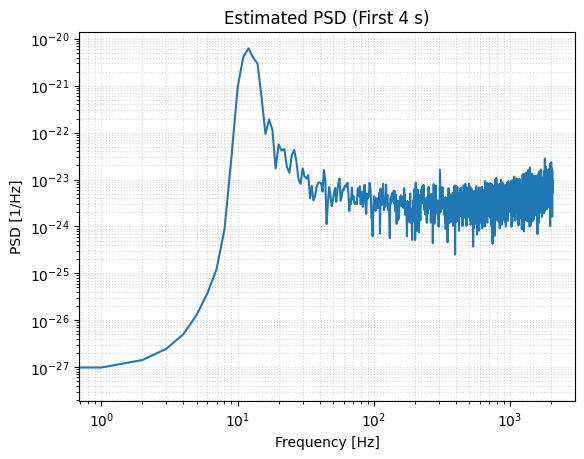

Estimated PSD Δf = 1.0 Hz
Data Δf = 0.05 Hz


In [78]:

#Packages from pycbc, obtained from: https://pycbc.org/pycbc/latest/html/pycbc.types.html
from pycbc.psd import welch
from pycbc.types import TimeSeries

#Generate the PSD data for the first 4 seconds (no GW, just noise)
psd_data = noise[:int(4.0 / delta_t)]


#Parameters needed to estimate PSD with Welch's Method
seg_len = 4096  #given sample rate
seg_stride = 2048   #half of given sample rate

#Equation for PSD estimation
psd_est = welch(psd_data, seg_len=seg_len, seg_stride=seg_stride, window='hann', avg_method='median')

#Plotting the PSD
plt.figure()
plt.loglog(psd_est.sample_frequencies, psd_est) #Logscaling is used for plotting very small values against very high values
plt.xlabel("Frequency [Hz]")
plt.ylabel("PSD [1/Hz]")
plt.title("Estimated PSD (First 4 s)")
plt.grid(True, which="both", ls=":", alpha=0.5) #Adding grid to make the logscaling more clear
plt.show()


#Finding the values for delta_f for estimated data
print("Estimated PSD Δf =", psd_est.delta_f, "Hz")

#Delta_f of full 20 s data
delta_f_data = 1.0 / 20.0
print("Data Δf =", delta_f_data, "Hz")


Now that we have the PSD we need to interpolate it to match our data and then limit the filter length of 1 / PSD. After this, we can directly use this PSD to filter the data. Since the data has been highpassed above 12 Hz, and will have low values below this we need to informat the function to not include frequencies below this frequency.

**Exercise 5:** Use the functions [interpolate](https://pycbc.org/pycbc/latest/html/pycbc.psd.html#pycbc.psd.estimate.interpolate) and [inverse_spectrum_truncation](https://pycbc.org/pycbc/latest/html/pycbc.psd.html#pycbc.psd.estimate.inverse_spectrum_truncation) to achieve a proper formatting of the PSD.

_Hint:_ `max_filter_len (int)` is $4 \times$ sampling_rate. Note that the original PSD has a minimum frequency of 12Hz.

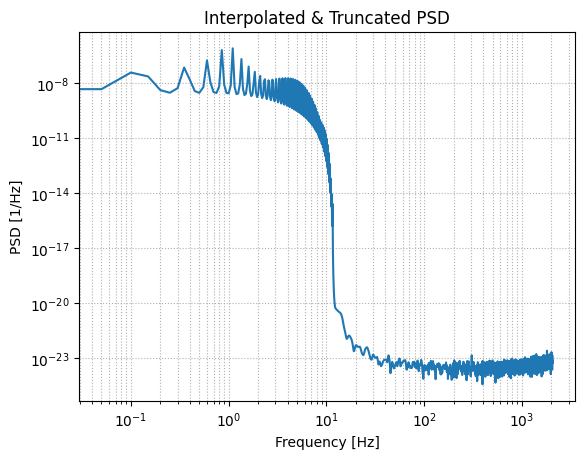

In [80]:

#Frequency of the DATA
delta_f_data = 1.0 / 20

#Interpolate PSD to match our data using the function given
psd_interpolate = interpolate(psd_est, delta_f=delta_f_data, length=length // 2 + 1) #Hermitian symmetry for FFT as Exercise 1

#Maximum length of the time-domain filter in samples
max_filter_len = 16384

#Smoothing of PSD according to inverse spectrum truncation equation
psd_final = inverse_spectrum_truncation(psd_interpolate, max_filter_len=max_filter_len, low_frequency_cutoff=12.0, trunc_method='hann')

#Plot final PSD
plt.figure()
plt.loglog(psd_final.sample_frequencies, psd_final)
plt.xlabel("Frequency [Hz]")
plt.ylabel("PSD [1/Hz]")
plt.title("Interpolated & Truncated PSD")
plt.grid(True, which="both", ls=":")
plt.show()


**In exercise 6 and 7 something went wrong, I am aware. I think I misused the functions as I tried using the same functions as in Tutorial 2. I have tried many ways to fix it, but I am unable to see what the solution is.**

Now that the PSD is ready, we can whiten the data. Before we used a PyCBC function, but mathematically this is defined as

\begin{equation}
\tilde{d_w}(f) = \tilde{d}(f)/S_{n}^{-1/2}(f)
\end{equation}
where $\tilde{d}$ and $\tilde{d_w}(f)$ are the Fourier transform of the coloured data and whitened data, respectively.

**Exercise 6:** Whiten the data using the interpolated PSD. Crop 5s at the beginning and the end to avoid border effects (_aliasing_) and bandpass it as in the previous exercise. Can you see the GW signal?

In [95]:
#Whitened data from the equation given
white_f = psd_interpolate/ psd_interpolate**0.5

#Whitened time data
white_ts = white_f.to_timeseries()

#Using the crop function from Tutorial 2 to avoid border effects
white_ts = white_ts.crop(5, 5)

#Bandpass the data as done in Tutorial 2
white_ts = white_ts.highpass_fir(12.0, max_filter_len)
white_ts = white_ts.lowpass_fir(300.0, max_filter_len)

#Plot the data
time = white_ts.sample_times
plt.figure(figsize=(10, 4))
plt.plot(time, white_ts, label="Whitened & bandpassed data")
plt.xlabel("Time [s]")
plt.ylabel("Whitened strain")
plt.title("Exercise 6: Whitened data")
plt.legend()
plt.show()







TypeError: to_timeseries does not support real types

So far, we buried a GW signal  $h(t)$ in stationary and Gaussian noise $n(t)$ with zero mean, such that $s(t) = h(t) + n(t)$. Given the optimal filter  $K(t)$,

\begin{equation}
\label{eq:filteredsignal}
\hat{s} = \int_{-\infty}^{\infty}  K(t)s(t) dt = \int_{-\infty}^{\infty} \tilde{K}(f)^{*}\tilde{s}(f) df, \quad \text{ where }  \tilde{s}(f) = \int_{-\infty}^{\infty} s(t)e^{-2 \pi i ft}dt
\end{equation}
where $\hat{s}$ is the filtered value of $s(t)$, $^*$ represents the complex conjugate, and $\tilde{\cdot }\ $ the Fourier transform.

The detection statistic that is maximised by the optimal filter $K(t)$  will be the SNR, defined as $\rho = S/N$. $S$ is the expected value of $\hat{s}$ when $h(t) \neq 0$, while $N$ is the squared root of the noise variance when $h(t) =0$. It can be demonstrated that the optimal filter $K(t)$ is the model of the GW signal itself, known as _template_.

The fundamental modelled detection technique is called "matched filtering", since the filter function is chosen to "match" the signal we are looking for. We can write the SNR between an unknown time series $s(t)$ and the template $h_{m}$ as

\begin{equation}
\label{eq:wienerscalar}
\rho =  4 \text{Re} \int_{0}^{\infty} \frac{\tilde{s}^{*}(f)}{S_{n}(f)} \tilde{h_{m}}(f) df.
\end{equation}



**Exercise 7:** Use the [matched_filter](https://pycbc.org/pycbc/latest/html/pycbc.filter.html#pycbc.filter.matchedfilter.matched_filter) function to filter the coloured data with the template. Crop the SNR time series 5s at each side and plot it together with the whitened data. Where is the GW signal? Note that the y-axis of the whitened data is _amplitude_ and the y-axis of the SNR timeseries is _SNR_.

How much is the maximum of the absolute value of the SNR time series? If it is larger than 5 it will generate a "trigger" for further analysis. Will the trigger be generated?

Note that the parameter space of GW signals is vast, so to find these signals, we will need to create a template bank and do this process for thousands of templates. Then, this becomes a high-performance computing problem!

_Hint_: you need to [resize](https://pycbc.org/pycbc/latest/html/pycbc.types.html#pycbc.types.array.Array.resize) the template and use [cyclic_time_shift](https://pycbc.org/pycbc/latest/html/pycbc.types.html#pycbc.types.frequencyseries.FrequencySeries.cyclic_time_shift)

In [96]:
#Copy template to make the naming easier
template = waveform_L1.copy()

#To obtain d(f) of exercise 6
data_f = data.to_frequencyseries()

#Shift with the assigned function
template = template.cyclic_time_shift(5.0)

#Apply the given snr function
snr = matched_filter(template, data_f, psd=psd_final, low_frequency_cutoff=12.0)

crop = int(5.0 / delta_t)
snr = snr[crop:-crop] #Crop 5 at beginning and end of plot
white_ts_crop = white_ts

#Obtain the time for the plot
time = snr.sample_times

#Making the plot of the whitened data and SNR: https://matplotlib.org/stable/gallery/subplots_axes_and_figures/subplots_demo.html
fig, ax1 = plt.subplots(figsize=(10,4))

ax1.plot(time, white_ts_crop, color='blue', alpha=0.6)
ax1.set_xlabel("Time [s]")
ax1.set_ylabel("Whitened strain")

ax2 = ax1.twinx()
ax2.plot(time, abs(snr), color='red')
ax2.set_ylabel("SNR")

plt.title("Matched filter")
plt.grid()
plt.show()




AttributeError: 'numpy.ndarray' object has no attribute 'to_frequencyseries'

Good job arriving at the end of the tutorial! This was a small peak at GW data analysis that I hope you found interesting.

There is a bonus track exercise if you are bored, but we can also have a chat about some more GW data analysis if you prefer.